In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append("../src/unet")

from data import EMDataset

DATA_DIR = Path("../data/raw")
PROB_DIR = Path("../data/prob_maps")

test_data = EMDataset(DATA_DIR, split="test", augment=False)

# Group patches by image index for stitching
from collections import defaultdict
groups = defaultdict(list)
for p in test_data.patches:
    groups[p["image_idx"]].append(p)


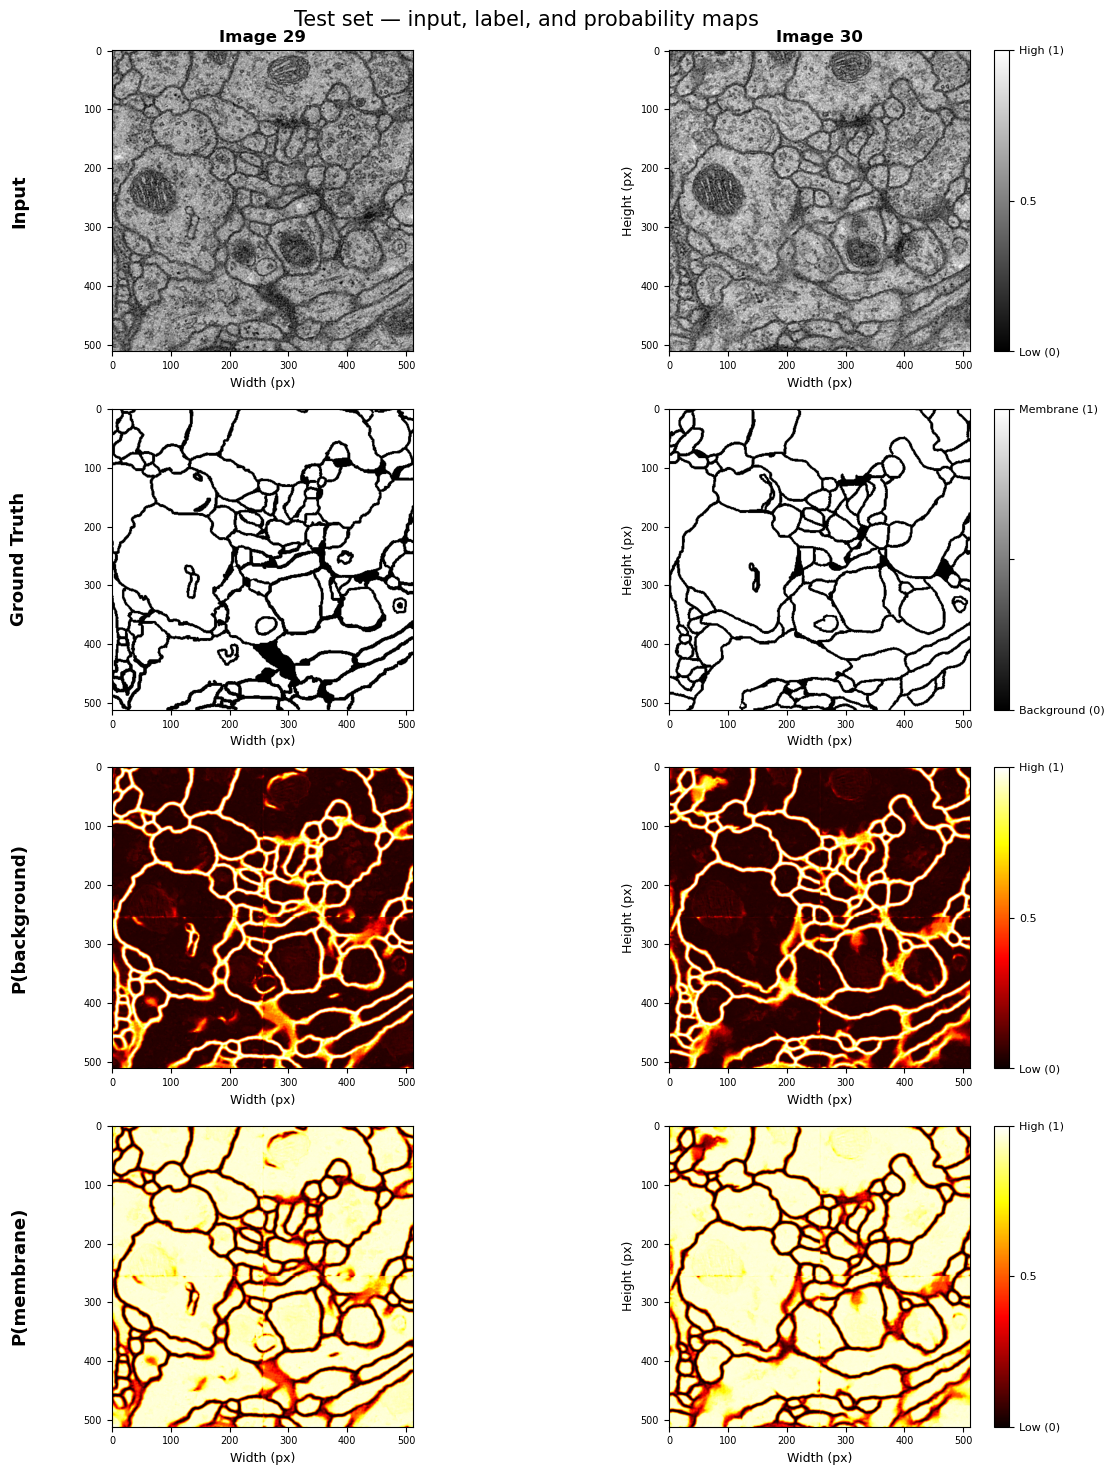

In [5]:
test_indices = sorted(groups.keys())

fig, axes = plt.subplots(4, len(test_indices), figsize=(6 * len(test_indices), 15))
row_labels = ["Input", "Ground Truth", "P(background)", "P(membrane)"]
cmaps      = ["gray",  "gray",         "hot",           "hot"]

for col, img_idx in enumerate(test_indices):
    patches = sorted(groups[img_idx], key=lambda p: (p["row"], p["col"]))

    full_image = np.zeros((512, 512), dtype=np.float32)
    full_label = np.zeros((512, 512), dtype=np.int64)
    for p in patches:
        r, c = p["row"], p["col"]
        full_image[r:r+256, c:c+256] = p["image"]
        full_label[r:r+256, c:c+256] = p["label"]

    prob_bg  = np.load(PROB_DIR / f"prob_background_{img_idx}.npy")
    prob_mem = np.load(PROB_DIR / f"prob_membrane_{img_idx}.npy")
    panels   = [full_image, full_label, prob_bg, prob_mem]

    for row, (data, cmap) in enumerate(zip(panels, cmaps)):
        im = axes[row, col].imshow(data, cmap=cmap, vmin=0, vmax=1)
        axes[row, col].set_xlabel(f"Width (px)", fontsize=9)
        axes[row, col].set_ylabel(f"Height (px)", fontsize=9)
        axes[row, col].tick_params(labelsize=7)

        # Colorbar only on the last column
        if col == len(test_indices) - 1:
            cbar = fig.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
            cbar.set_ticks([0, 0.5, 1])
            if row == 1:   # ground truth: binary
                cbar.set_ticklabels(["Background (0)", "", "Membrane (1)"])
            else:
                cbar.set_ticklabels(["Low (0)", "0.5", "High (1)"])
            cbar.ax.tick_params(labelsize=8)

        if col == 0:
            axes[row, col].set_ylabel(row_labels[row], fontsize=13, fontweight="bold", labelpad=40)

    axes[0, col].set_title(f"Image {img_idx:02d}", fontsize=12, fontweight="bold")

plt.suptitle("Test set — input, label, and probability maps", fontsize=15)
plt.tight_layout()
plt.show()
